AI use in computational steps: 
- "Processing the different labels of the data set." AI was used to make sure the categories and measurements were separated correctly, and also read horizontally
- "Splitting up the data into training and testing categories." AI was used to help with the random state and the stratify, it was used to help make sure that the data, when split, would be the same groups if rerun, and also that it was an even split for each category
- "Visualizing the different categories as bar graphs." AI was used to ensure each category was displayed. It also made it easy to apply a consistent code sequence across the entire data set, and it helped title the y-axis only once to save space 
- "Evaluating the performance of the network by checking the outputs." AI was used to help make sure that either all 5 or all 9 categories are being represented

In [1]:
#Download all the necessary programs to run the data in this experiment
import numpy as np #This program is used to work with arrays, meaning a variable that can hold more than one value at a time
import matplotlib #This program helps visualize data by creating static, animated, or interactive visuals
import matplotlib.pyplot as plt #This program helps create line plots, pie charts, bar charts, scatter plots, and histograms 
import tensorflow as tf #This helps facilitate the development of machine learning 
import pandas as pd #This aids in picturing data sets that are working with relational and labeled data
from sklearn.model_selection import train_test_split #This is evaluating how well the model does on new (never seen) data
from sklearn.preprocessing import StandardScaler #This normalizes the data to all be on a similar scale, typically a mean of 0 and standard deviation of 1
from tensorflow.keras import layers, models #Layers provides the building blocks for the neural network, models is used to group all the layers into a functioning network
from tensorflow.keras.layers import Dense #Con2D extracts spatial features, maxpooling2D is a method used to downsize the data sample of spatial features, flatten turns multi-dimensional data into one vector/dimension, dense implements a connected neural network 
from tensorflow.keras.models import Sequential #This program creates a neural network model by stacking layers step-by-step
from tensorflow.keras.models import Model #This program defines, trains, evaluates, and runs inference on the deep-learning model

In [2]:
#Load the data set that will be analyzed for the experiment
df = pd.read_csv('anglerfish_data_grouping_13.csv')

In [3]:
#Processing the different labels of the dataset
X = df.drop(columns=['Unnamed: 0', 'Categories']).values #AI-GENERATED. Excluding the species and category columns for the data portion
Y = df['Categories'].values #AI-GENERATED. Only looking at the column labeled categories 

In [4]:
#Normalizing the data set to ensure bigger numbers are not favored over smaller values, depending on which measurements are being looked at (body size vs. tooth length)
scaler = StandardScaler() #This scales the measurements to have a mean of 0 and a variance of 1
X_scaled = scaler.fit_transform(X) #Transforming the all of the measurements

In [5]:
#Verifying the data is being read correctly 
print("First row of data:") 
print(df.iloc[0]) #This will show you the data that is being included for the X label and the Y label, ensuring the previous code accurately split the data

First row of data:
Unnamed: 0     Antennarius maculatus
Categories                         0
avg.t                      -2.480424
avg.t.u                    -2.806099
avg.w                      -4.099278
avg.w.u                     -4.24535
avg.d                      -3.095663
avg.d.u                    -3.415146
gape                       -0.103085
premax                     -0.748916
lower.jaw                  -0.242583
tooth.reg                  -0.481207
desc.proc                  -1.295436
tooth.count                 4.615121
meanspace                  -3.242699
Name: 0, dtype: object


In [6]:
#Splitting up the data into training and testing categories
train_measurements, test_measurements, train_labels, test_labels = train_test_split(
    X_scaled, Y, 
    test_size=0.2, #0.2 is set due to the 80/20 split of training data and testing data, given the small sample size
    random_state=42, #AI-GENERATED. A random state needs to be set; any number can be used for this, ensuring that if the network was rerun, the same testing and training groups were used
    stratify=Y #AI-GENERATED. This ensures that each category in the data set is represented proportionally in both the training and testing sets
)

In [7]:
#Verifying that this is an accurate split between the groups
print(len(train_measurements)) #Verifying that the measurements were accuratly split
print(len(test_measurements))
print(len(test_labels)) #This is verifying that the labels were also accurately split
print(len(train_labels)) 

40
10
10
40


In [8]:
#Verifying that the data was split proportionally into the two different categories
print("Category counts in training set:")
print(pd.Series(train_labels).value_counts().sort_index()) #Ensuring that the AI-GENERATED code for stratifying was accurate (stratify=Y) 
print(pd.Series(test_labels).value_counts().sort_index())

Category counts in training set:
0     7
1    11
2     5
3     3
4     3
5     2
6     4
7     2
8     3
Name: count, dtype: int64
0    1
1    3
2    1
3    1
5    1
6    1
7    1
8    1
Name: count, dtype: int64


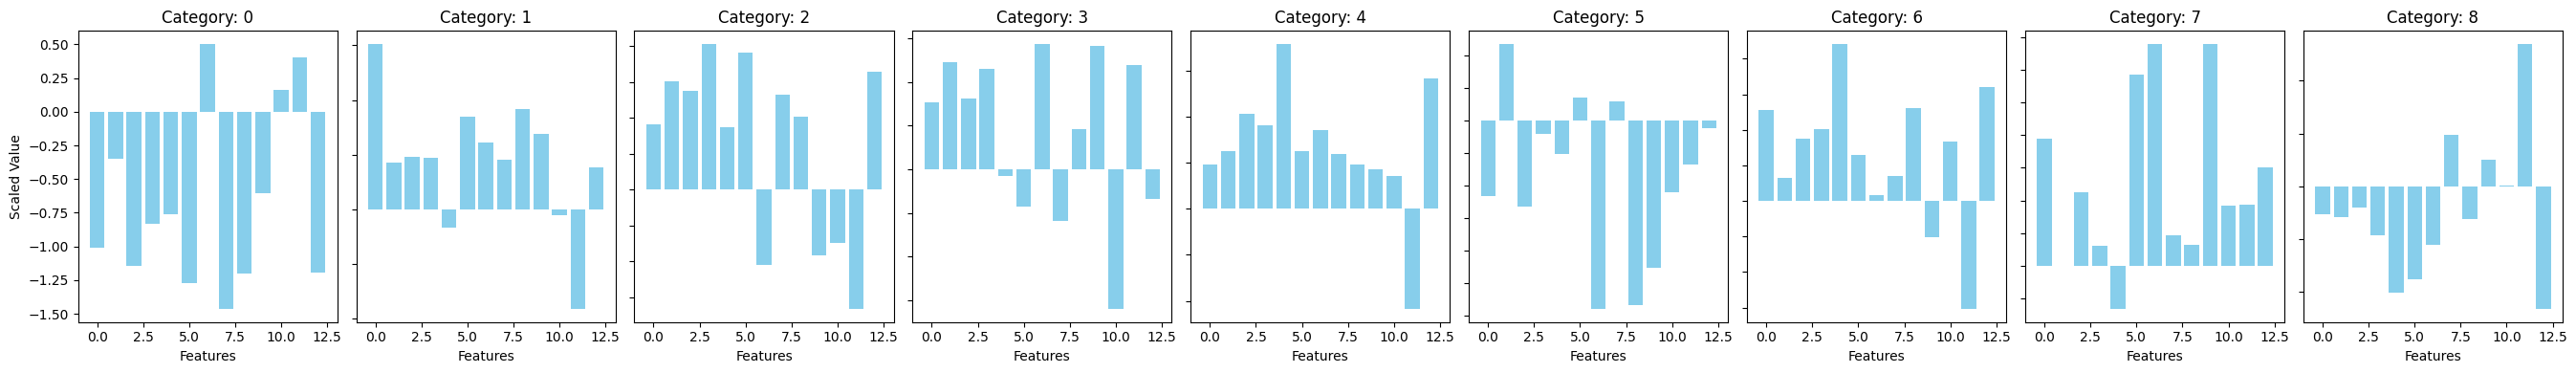

In [9]:
#Visualizing the different categories as bar graphs
unique_labels = np.unique(train_labels) #AI GENERATED. This is generating a list of all the different (unique) categories in this data set
representative_indices = [np.where(train_labels == lbl)[0][0] for lbl in unique_labels] #AI GENERATED. This goes through the list and finds an example for each category
fig, axes = plt.subplots(1, 9, figsize=(3 * 9, 4)) #Adjust the figure size to be wider so the bar charts are readable
for i, idx in enumerate(representative_indices): #AI GENERATED. Using idx instead of ind because idx represents more of a collection of indices, whereas ind refers to a specific index vector 
    label = train_labels[idx] #AI GENERATED. Ensuring that the idx is looking through the labels and not the measurements
    axes[i].bar(range(train_measurements.shape[1]), train_measurements[idx], color='skyblue') #AI GENERATED. The train_measurements.shape aided in plotting the 13 measurements for each fish that was chosen from the representative indices
    axes[i].set_title(f"Category: {label}")
    axes[i].set_xlabel("Features") 
    if i == 0: #AI GENERATED. Only show Y-axis labels on the first plot to save space
        axes[i].set_ylabel("Scaled Value") #AI GENERATED. The first y-axis is displayed is titled scaled value
    else:
        axes[i].set_yticklabels([]) #AI GENERATED. If any other y-axis besides the first is displayed, it will not title the axis 
plt.tight_layout()
plt.show()

In [10]:
#Training the Neural Network
model = models.Sequential([
    layers.Input(shape=(train_measurements.shape[1],)), #This is telling the model to expect rows with 13 measurements
    layers.Dense(32, activation='relu'), #32 was chosen to try to have the model not overfit, large values will cause the model to overfit, while smaller values will cause it to underfit "relu" is an activation function that introduces non-linearity to models to help them learn more complex patterns
    layers.Dense(16, activation='relu'), #16 was chosen because a smaller number is needed on the second line to create a funnel feature and try and prevent memorization by repetition
    layers.Dense(9, activation='softmax')]) #9 output categories (0-8), "softmax" is an activation function that converts arbitrary numbers into a probability distribution

model.compile(
    optimizer='adam', #"adam" is an optimization algorithm that trains neural networks 
    loss='sparse_categorical_crossentropy', #"sparse_categorical_crossentropy" is a loss function that is used for multi-class classification problems
    metrics=['accuracy'])

In [11]:
#Training the neural network for the anglerfish measurements and labels
history = model.fit(
    train_measurements, 
    train_labels, 
    epochs=40, #Using 40 Epochs due to a small sampling size to ensure the neural network is trained on the data
    validation_split=0.2, #This is the 80/20 split to check the performance 
    verbose=1)

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - accuracy: 0.0625 - loss: 2.6529 - val_accuracy: 0.1250 - val_loss: 2.4554
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0625 - loss: 2.6222 - val_accuracy: 0.1250 - val_loss: 2.4387
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0625 - loss: 2.5923 - val_accuracy: 0.1250 - val_loss: 2.4223
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0625 - loss: 2.5630 - val_accuracy: 0.1250 - val_loss: 2.4063
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0625 - loss: 2.5347 - val_accuracy: 0.1250 - val_loss: 2.3908
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0625 - loss: 2.5071 - val_accuracy: 0.1250 - val_loss: 2.3762
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0625 - loss: 2.4803 - val_accuracy: 0.1250 - val_loss: 2.3621
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0625 - loss: 2.4545 - val_accuracy: 0.1250 - val_loss: 2.3485

In [12]:
#Evaluating the performance of the network by checking the outputs
def view_classify(probs, actual_label):
    classes = ['Cat 0', 'Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5', 'Cat 6', 'Cat 7', 'Cat 8'] #AI GENERATED. Wanted to make sure that all classes are represented in plots
    plt.bar(classes, probs) #Creating a bar graph of probabilities and categories 
    plt.title(f"Actual Category: {actual_label} | Predicted Category: {np.argmax(probs)}") #Having title represent which category you are looking at, and what the network predicted
    plt.ylabel('Probability') #Have y-axis be labeled as probability 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Probability for each class:
[0.11812334 0.1299605  0.10639445 0.1123837  0.12215554 0.11677634
 0.09216417 0.09460655 0.10743541]


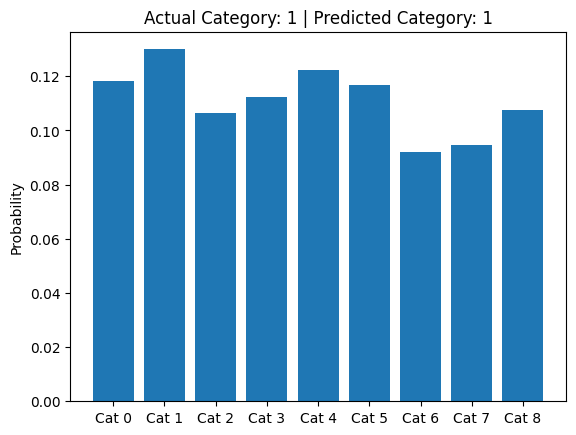

In [17]:
#Let's look at a singular fish from the test set to see how well the network predicted the category
features, label = test_measurements[1], test_labels[1] #Different numbers will show different predictions with the actual category as well
probabilities = model.predict(features.reshape(1, 13)) #Reshaping to fit the measurements
view_classify(probabilities[0], label)
print("Probability for each class:") #Printing the probability as numbers for all categories 
print(probabilities[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Probability for each class:
[0.07307699 0.06944656 0.0714154  0.16693841 0.20507935 0.10812227
 0.16553384 0.0733979  0.06698927]


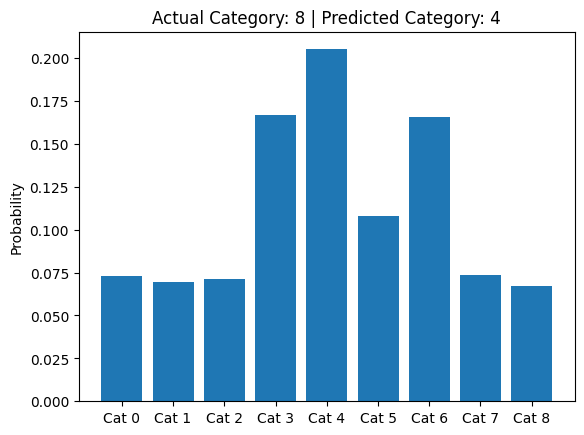

In [18]:
#Can look at a different fish from the data set (different category)
features, label = test_measurements[2], test_labels[2]
probabilities = model.predict(features.reshape(1, 13))
view_classify(probabilities[0], label)
print("Probability for each class:")
print(probabilities[0])

In [19]:
#Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_measurements, test_labels) #Calculating the accuracy and loss of the test data predictions
print(f'Accuracy of the neural network on the {test_measurements.shape[0]} test samples: {test_accuracy*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4000 - loss: 2.1477
Accuracy of the neural network on the 10 test samples: 40.00%


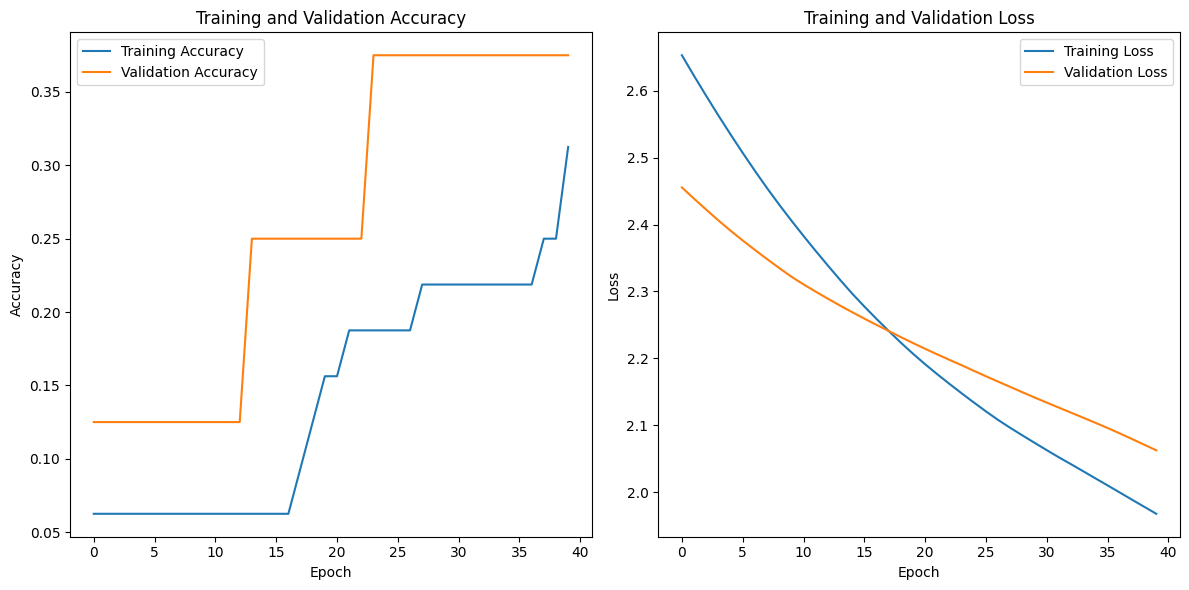

In [20]:
#Creating the training and validation accuracy graphs and the training and validation loss
#Making abbreviations for easier coding of word accuracy
acc = history.history['accuracy'] #Switched accuracy to 'acc' to make it easier to code
val_acc = history.history['val_accuracy'] #Switched val_accuracy to 'val_acc' to make it easier to code

#Creating training and validation accuracy
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='upper left')

#Creating training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


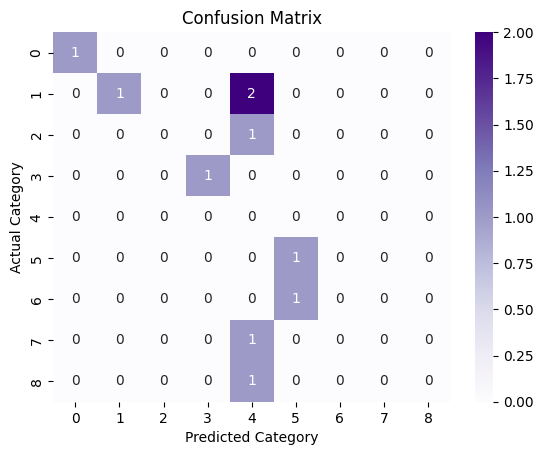

In [25]:
#Download the necessary libraries for creating a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #confusion_matrix calculates the numbers within the confusion matrix, comparing the true grouping to the predicted grouping
#ConfusionMatrixDisplay provides an automatic, professional-looking confusion matrix 
import seaborn as sns #Makes creating complex graphs (heatmaps or scatterplots) much easier and more aesthetically pleasing due to less code

#Extracting the predicted categories from the probability scores  
predictions = model.predict(test_measurements) #Runs input data through trained model for probability distribution
categories = np.argmax(predictions, axis=1) #This is scanning the probabilities for the maximum value to then create the 0-3 score (0 never prediction to 3 always correctly predicted) 

# Create the confusion matrix
cm = confusion_matrix(test_labels, categories) #Collect the actual numbers being displayed
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples') #Helping create this highly difficult graph in one code line
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix')
plt.show()